# Bank Loan Approval Prediction
This notebook walks through the full workflow for predicting whether a bank loan application should be approved: loading the data, cleaning it, exploring it visually, engineering features, training multiple machine learning models, and comparing their performance.

## 0. Import Libraries
All the libraries used throughout this notebook are imported together here for clarity: `pandas` for data handling, `matplotlib`/`seaborn`/`plotly` for visualization, and `scikit-learn` modules for preprocessing, model training, and evaluation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

## 1. Load the Dataset
We start by importing `pandas` and reading the loan applicants data from the Excel file `Loan_Applicants_1000.xlsx` into a DataFrame called `data`. We then print the first 5 rows with `data.head()` to get a quick look at the columns and the type of values they contain.

In [2]:
data = pd.read_excel(r"Loan_Applicants_1000.xlsx") # Loaded the dataset
print(data.head()) # viewed first 5 data for understanding the attributes

    Loan_ID  Gender Married Dependents     Education Self_Employed  \
0  LP100000    Male      No          1  Not Graduate            No   
1  LP100001  Female     Yes          1  Not Graduate            No   
2  LP100002    Male     Yes          0      Graduate            No   
3  LP100003    Male      No          0  Not Graduate           Yes   
4  LP100004    Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0            13164               6964         382               120   
1             9719              13161          50               360   
2            24964              14635         237               300   
3            19869               8075         105               360   
4            11213              13913         596               360   

   Credit_History Property_Area Loan_Status  
0               1     Semiurban           Y  
1               1         Rural           Y  
2             

## 2. Inspect Dataset Structure
`data.info()` gives us an overview of the dataset — the number of rows and columns, the column names, their data types (numeric vs object/categorical), and how many non-null values each column has. This helps us spot which columns need cleaning or encoding later.

In [3]:
data.info() # overviewed the dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            1000 non-null   object
 1   Gender             1000 non-null   object
 2   Married            1000 non-null   object
 3   Dependents         1000 non-null   object
 4   Education          1000 non-null   object
 5   Self_Employed      1000 non-null   object
 6   ApplicantIncome    1000 non-null   int64 
 7   CoapplicantIncome  1000 non-null   int64 
 8   LoanAmount         1000 non-null   int64 
 9   Loan_Amount_Term   1000 non-null   int64 
 10  Credit_History     1000 non-null   int64 
 11  Property_Area      1000 non-null   object
 12  Loan_Status        1000 non-null   object
dtypes: int64(5), object(8)
memory usage: 101.7+ KB


## 3. Check Missing Values (Per Column)
We use `data.isnull().sum()` to count how many missing (NaN) values exist in each individual column. This tells us exactly which features need to be cleaned before we can train a model.

In [4]:
data.isnull().sum() # checked for missing values

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## 4. Check Total Missing Values
Here we sum the missing value counts across all columns with `data.isnull().sum().sum()` to get a single number representing the total amount of missing data in the entire dataset.

In [5]:
data.isnull().sum().sum() # checked the total of missing values in dataset

np.int64(0)

## 5. Check for Duplicate Rows
`data.duplicated().sum()` counts how many rows in the dataset are exact duplicates of another row. Duplicate records can bias the model, so we need to know how many exist before removing them.

In [6]:
data.duplicated().sum() # checked for duplicates

np.int64(0)

## 6. Remove Duplicate Rows
We use `data.drop_duplicates()` to remove any duplicate rows found in the previous step, ensuring each record in the dataset represents a unique loan application.

In [7]:
data.drop_duplicates() # droped the duplicates

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,Male,No,1,Not Graduate,No,13164,6964,382,120,1,Semiurban,Y
1,LP100001,Female,Yes,1,Not Graduate,No,9719,13161,50,360,1,Rural,Y
2,LP100002,Male,Yes,0,Graduate,No,24964,14635,237,300,1,Semiurban,Y
3,LP100003,Male,No,0,Not Graduate,Yes,19869,8075,105,360,1,Semiurban,Y
4,LP100004,Male,No,0,Graduate,No,11213,13913,596,360,1,Rural,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,LP100995,Male,No,1,Graduate,No,2489,12563,65,360,1,Semiurban,Y
996,LP100996,Male,Yes,1,Not Graduate,No,13976,10737,472,360,1,Rural,Y
997,LP100997,Female,Yes,2,Not Graduate,Yes,9946,8867,638,360,1,Semiurban,Y
998,LP100998,Female,Yes,3+,Graduate,No,6211,1823,642,300,1,Urban,Y


## 7. Handle Missing Values
Now we fill in the missing values so the dataset is complete:
- **Numeric columns** (`ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`) are filled with their **median**, since the median is less sensitive to outliers than the mean.
- **Categorical columns** (`Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `Credit_History`, `Property_Area`) are filled with their **mode** (the most frequent value).
- The `Dependents` column has a value `"3+"` which we replace with the integer `3` so the column is fully numeric.
- Finally, we drop the `Loan_ID` column since it's just a unique identifier and holds no predictive value for the model.

In [8]:
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"] # classified the numeric columns
for col in num_cols:
   data[col].fillna(data[col].median()) # used fillna to fill missing values with median

cate_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Credit_History", "Property_Area"] # classified the frequency colums
for col in cate_cols:
    data[col] = data[col].fillna(data[col].mode()[0]) # used fillna to fill the missing values with mode with (default'0')

data["Dependents"] = data["Dependents"].replace("3+", 3) # fixing the string data type to integer

data = data.drop("Loan_ID",axis = 1) # droping unique values 'Loan_ID' to imporve the data consistency

## 8. Verify Data Cleaning
We re-run the null value check, duplicate check, and duplicate removal one more time to confirm that after filling missing values, the dataset is now clean with no remaining nulls or duplicates.

In [9]:
data.isnull().sum() # checking null values after filling missing values 
data.duplicated().sum() # checking duplicate values after filling missing values 
data.drop_duplicates() # droping if any duplicate exist

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,1,Not Graduate,No,13164,6964,382,120,1,Semiurban,Y
1,Female,Yes,1,Not Graduate,No,9719,13161,50,360,1,Rural,Y
2,Male,Yes,0,Graduate,No,24964,14635,237,300,1,Semiurban,Y
3,Male,No,0,Not Graduate,Yes,19869,8075,105,360,1,Semiurban,Y
4,Male,No,0,Graduate,No,11213,13913,596,360,1,Rural,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Male,No,1,Graduate,No,2489,12563,65,360,1,Semiurban,Y
996,Male,Yes,1,Not Graduate,No,13976,10737,472,360,1,Rural,Y
997,Female,Yes,2,Not Graduate,Yes,9946,8867,638,360,1,Semiurban,Y
998,Female,Yes,3,Graduate,No,6211,1823,642,300,1,Urban,Y


## 9. Detect and Handle Outliers
For the numeric columns most likely to have extreme values (`ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`), we use the **IQR (Interquartile Range) method** to detect outliers:
- Calculate Q1 (25th percentile) and Q3 (75th percentile), then IQR = Q3 − Q1.
- Any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is considered an outlier.
- We print how many outliers exist in each column, then **cap** (clip) those extreme values to the lower/upper bounds instead of removing the rows, so we keep all the data while reducing the influence of extreme values.

In [10]:
# checking for outliers in columns with large values and variance
outliers_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"] 

for col in outliers_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    
    IQR = Q3 - Q1
        
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
        
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(col,":",len(outliers),"outliers")
        
    data[col] = data[col].clip(lower, upper) # Caped the Value with clip function

ApplicantIncome : 0 outliers
CoapplicantIncome : 0 outliers
LoanAmount : 0 outliers


## 10. Encode Categorical Variables
Machine learning models need numeric input, so we use scikit-learn's `LabelEncoder` to convert categorical text columns (`Gender`, `Married`, `Education`, `Self_Employed`, `Property_Area`, `Loan_Status`) into numeric codes (e.g. 0 and 1). We then print the first few rows to confirm the encoding worked correctly.

In [11]:
# Used LabelEncoder for encoding the values to machine understandable 0s and 1s
le = LabelEncoder()
columns = ["Gender", "Married", "Education", "Self_Employed", "Property_Area", "Loan_Status"]

for col in columns:
    data[col] = le.fit_transform(data[col])

print(data.head())

   Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0          1          1              0            13164   
1       0        1          1          1              0             9719   
2       1        1          0          0              0            24964   
3       1        0          0          1              1            19869   
4       1        0          0          0              0            11213   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               6964         382               120               1   
1              13161          50               360               1   
2              14635         237               300               1   
3               8075         105               360               1   
4              13913         596               360               1   

   Property_Area  Loan_Status  
0              1            1  
1              0            1  
2              1          

## 11. Scale Numerical Features
We use `StandardScaler` to standardize the numeric columns (`ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`) so they all have a mean of 0 and a standard deviation of 1. This puts all features on a comparable scale, which helps distance-based and gradient-based models train faster and more accurately.

In [12]:
# Used StandardScaler for scaling the values within range of 0 to 1 to improve the training speed and accuracy 
scaler = StandardScaler()
features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

data[features] = scaler.fit_transform(data[features])

print(data.head())

   Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0          1          1              0        -0.002565   
1       0        1          1          1              0        -0.505726   
2       1        1          0          0              0         1.720891   
3       1        0          0          1              1         0.976738   
4       1        0          0          0              0        -0.287519   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0          -0.140149    0.069945         -2.144661               1   
1           1.277873   -1.718406          0.510444               1   
2           1.615160   -0.711112         -0.153332               1   
3           0.114075   -1.422143          0.510444               1   
4           1.449949    1.222677          0.510444               1   

   Property_Area  Loan_Status  
0              1            1  
1              0            1  
2              1          

## 12. Descriptive Statistics & Grouped Analysis
- `data.describe()` gives summary statistics (mean, std, min, max, quartiles) for all numeric columns.
- We group the data by `Property_Area` and look at the proportion of approved vs rejected loans in each area to see if location affects approval rates.
- We build a pivot table comparing `Credit_History` against `Loan_Status` to see how strongly credit history is related to loan approval.

In [13]:
data.describe() # Descriptive Statistics

property_group = data.groupby("Property_Area")["Loan_Status"].value_counts(normalize=True).unstack() # grouping by Property_Area to see approval rates (0 = rejected, 1 = approved)
print(property_group)

credit_pivot = pd.pivot_table(data, index="Credit_History", columns="Loan_Status", aggfunc="size", fill_value=0)# analyzing how Credit_History affects Loan_Status
print(credit_pivot)

Loan_Status           0         1
Property_Area                    
0              0.053333  0.946667
1              0.031008  0.968992
2              0.043814  0.956186
Loan_Status      0    1
Credit_History         
0               36  126
1                5  833


## 13. Correlation Heatmap & Income vs Status Boxplot
We create:
- A **correlation heatmap** showing how strongly each numeric feature is related to the others (and to the target, `Loan_Status`).
- A **boxplot** comparing `ApplicantIncome` for rejected vs approved applicants, to visually check whether income influences approval.

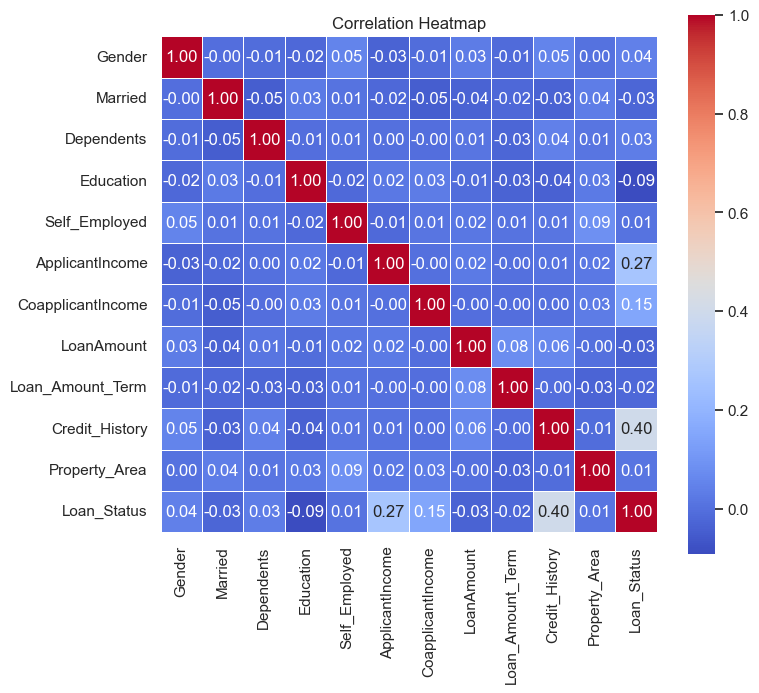

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22728\2759070670.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Rejected", "Approved"])


Text(0.5, 1.0, 'Applicant Income vs Loan Status')

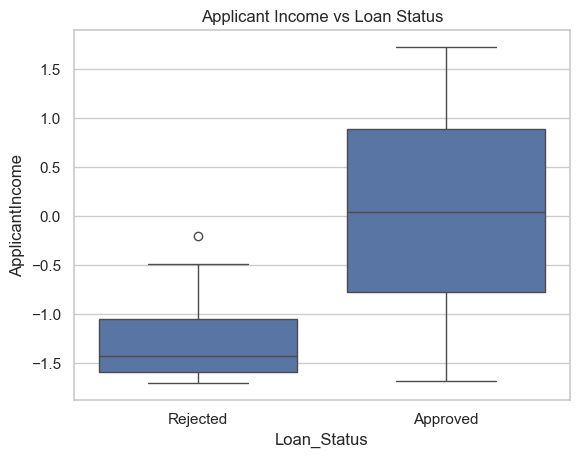

In [14]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 7))
sns.heatmap(data.corr(), annot = True, cmap = "coolwarm", fmt = "0.2f", linewidths = 0.5, square = True)
plt.title("Correlation Heatmap")
plt.show()

ax = sns.boxplot(x = "Loan_Status", y = "ApplicantIncome", data = data)
ax.set_xticklabels(["Rejected", "Approved"])
plt.title("Applicant Income vs Loan Status")

**How to read this:** The heatmap shows the correlation between every pair of numeric features, from -1 (strong negative relationship) to +1 (strong positive relationship). Darker/warmer cells close to +1 or -1 indicate features that move together strongly; cells near 0 mean the two features have little linear relationship. Look at the `Loan_Status` row/column specifically to see which features are most correlated with loan approval.

**How to read the boxplot:** Each box shows the spread (median, quartiles, and outliers) of `ApplicantIncome` for the Rejected group vs the Approved group. If the boxes and medians look very similar, it suggests income alone doesn't cleanly separate approved from rejected applicants; if one group's box sits noticeably higher, income likely plays a bigger role.

## 14. Loan Status Distribution
A **count plot** showing how many applications were rejected vs approved, giving us a sense of whether the target classes are balanced or imbalanced.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22728\3009748693.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_1.set_xticklabels(["Rejected", "Approved"])


Text(0.5, 1.0, 'Distribution of Loan Status')

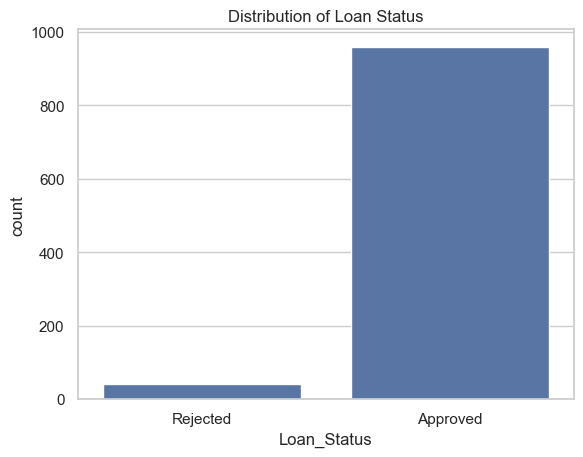

In [15]:
ax_1 = sns.countplot(x = "Loan_Status", data = data)
ax_1.set_xticklabels(["Rejected", "Approved"])
plt.title("Distribution of Loan Status")

**How to read this:** Each bar shows how many applications fall into the Rejected vs Approved category. A big difference in bar heights means the dataset is **imbalanced** (many more approvals than rejections, or vice versa) — which is important context when judging model accuracy later, since a model can look accurate just by favoring the majority class.

## 15. Loan Amount Histogram
A **histogram** of the `LoanAmount` column to visualize the distribution/spread of loan amounts requested by applicants.

Text(0, 0.5, 'Frequency')

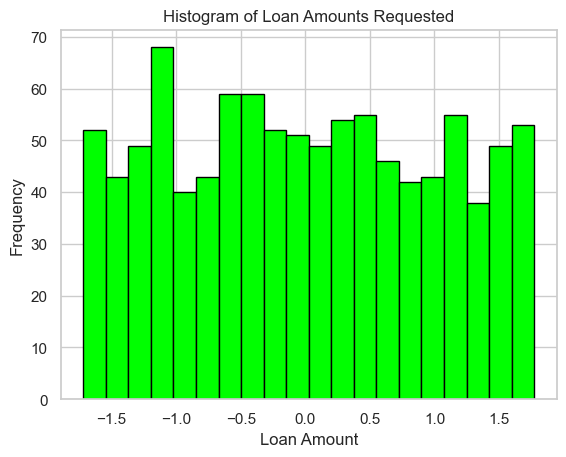

In [16]:
plt.hist(data["LoanAmount"], bins = 20, color = "Lime", edgecolor = "black")
plt.title("Histogram of Loan Amounts Requested")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

**How to read this:** The histogram bins loan amounts into ranges (x-axis) and shows how many applicants requested a loan in each range (y-axis, frequency). A tall bar on the left with a long tail to the right means most applicants request smaller loans, while a few request much larger ones — useful for spotting the general borrowing pattern and any skew in the data.

## 16. Interactive Scatter Plot (Plotly)
An interactive **Plotly scatter plot** of `ApplicantIncome` vs `LoanAmount`, colored by `Loan_Status`, with `Education` and `Credit_History` shown on hover. This lets us explore relationships between income, loan amount, and approval outcome interactively.

In [17]:
pio.renderers.default = "iframe" 

fig_plotly = px.scatter(data, 
                        x = "ApplicantIncome", 
                        y = "LoanAmount", 
                        color = "Loan_Status",
                        hover_data = ["Education", "Credit_History"],
                        title = "Interactive Scatter: Applicant Income vs Loan Amount")

fig_plotly.show()

**How to read this:** Each point is one applicant, plotted by `ApplicantIncome` (x-axis) against `LoanAmount` (y-axis), and colored by `Loan_Status` (approved vs rejected). Hovering over a point also shows `Education` and `Credit_History`. Look for whether approved and rejected points cluster in different regions (e.g. higher income or lower loan amounts skewing toward approval) — that pattern would suggest income and loan amount influence the approval outcome. Because it's interactive, you can zoom and hover to inspect individual applicants.

## 17. Train/Test Split & Logistic Regression
We split the cleaned, encoded, and scaled data into features (`X`) and target (`y`, i.e. `Loan_Status`), then use `train_test_split` to create an 80% training set and a 20% testing set. We then train our first model, **Logistic Regression**, on the training data and use it to predict loan approval on the test set (`y_lr`).

In [64]:
X = data.drop("Loan_Status", axis=1) # Input Features for training 
y = data["Loan_Status"] # Output (or) Target 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42) # Split the dataset 80% Training, 20% Testing

lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

y_lr = lr.predict(X_test)

## 18. Decision Tree Classifier
We train a **Decision Tree Classifier**, which learns a set of if/else rules from the training data, and use it to predict loan approval status on the test set (`y_dtc`).

In [31]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

y_dtc = dtc.predict(X_test)

## 19. Random Forest Classifier
We train a **Random Forest Classifier** — an ensemble of 100 decision trees — which typically performs better and generalizes more reliably than a single tree. Predictions on the test set are stored in `y_rfc`.

In [32]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_rfc = rfc.predict(X_test)

## 20. K-Nearest Neighbors (KNN) Classifier
We train a **K-Nearest Neighbors** model with `k=5`, which classifies each applicant based on the majority loan outcome among their 5 most similar applicants in the training data. Predictions are stored in `y_knnc`.

In [33]:
knnc = KNeighborsClassifier(n_neighbors=5)
knnc.fit(X_train, y_train)

y_knnc = knnc.predict(X_test)

## 21. Model Evaluation & Comparison
Finally, we evaluate all four trained models (Logistic Regression, Decision Tree, Random Forest, KNN) on the test set using **Accuracy, Precision, Recall, F1 Score, and ROC-AUC**. The results are collected into a comparison table (`results_df`) and sorted by accuracy, so we can clearly see which model performs best for predicting loan approval.

In [34]:
models = {
    "Logistic Regression": y_lr,
    "Decision Tree": y_dtc,
    "Random Forest": y_rfc,
    "K-Nearest Neighbors": y_knnc
}

evaluation_results = [] # Initializing a list to store our evaluation metrics

for i, (model_name, y_pred) in enumerate(models.items()):
    accuracy = accuracy_score(y_test, y_pred) # Calculating metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4), # Storing metrics for the final comparison table
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })
    
results_df = pd.DataFrame(evaluation_results) # Creating the Model Comparison Report
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression     0.990     0.9897  1.0000    0.9948   0.8750
1        Random Forest     0.975     0.9746  1.0000    0.9871   0.6875
2        Decision Tree     0.965     0.9843  0.9792    0.9817   0.8021
3  K-Nearest Neighbors     0.965     0.9695  0.9948    0.9820   0.6224
